In [2]:
import requests

url = "https://example/url"

try:
    response = requests.get(url)
    response.raise_for_status()  # raises error for 4xx/5xx

    data = response.json()
    print("Success:", data)

except requests.exceptions.RequestException as e:
    print("Request failed:", e)


Request failed: HTTPSConnectionPool(host='example', port=443): Max retries exceeded with url: /url (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))


In [27]:
import requests
import pandas as pd 
url = "https://api.tvmaze.com/search/shows?q=girls"

response = requests.get(url)
if response.status_code == 200:    
    data = response.json()    
#print(data)
else:   
    print(f"Error:{response.status_code}")
pd.set_option('display.max_colwidth', None)
df = pd.DataFrame(data)
print(df)

      score  \
0  0.891644   
1  0.876614   
2  0.683959   
3  0.683862   
4  0.683764   
5  0.681226   
6  0.680372   
7  0.680264   
8  0.679718   
9  0.679608   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [5]:
import requests
import json
import pprint

url = "https://api.tvmaze.com/search/shows"
params = {"q":"girls"}
response = requests.get(url,params)
if response.status_code == 200:   
     #print(response.text)
    data = json.loads(response.text)
    pprint.pprint(data)
else:    
    print(f"Error:{response.status_code}")

[{'score': 0.89164364,
  'show': {'_links': {'previousepisode': {'href': 'https://api.tvmaze.com/episodes/1079686',
                                          'name': 'Latching'},
                      'self': {'href': 'https://api.tvmaze.com/shows/139'}},
           'averageRuntime': 30,
           'dvdCountry': None,
           'ended': '2017-04-16',
           'externals': {'imdb': 'tt1723816',
                         'thetvdb': 220411,
                         'tvrage': 30124},
           'genres': ['Drama', 'Romance'],
           'id': 139,
           'image': {'medium': 'https://static.tvmaze.com/uploads/images/medium_portrait/31/78286.jpg',
                     'original': 'https://static.tvmaze.com/uploads/images/original_untouched/31/78286.jpg'},
           'language': 'English',
           'name': 'Girls',
           'network': {'country': {'code': 'US',
                                   'name': 'United States',
                                   'timezone': 'America/New_Yor

In [7]:
import requests
import pandas as pd

# Correct URL for CoinGecko markets endpoint
url = "https://api.coingecko.com/api/v3/coins/markets"

# Parameters for the API request
params = {
    'vs_currency': 'usd',
    'per_page': 10
}

# Make the request
response = requests.get(url, params=params)

# Convert JSON → DataFrame
if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    print(df)
else:
    print(f"Error: {response.status_code}")


             id      symbol          name  \
0       bitcoin         btc       Bitcoin   
1      ethereum         eth      Ethereum   
2        tether        usdt        Tether   
3   binancecoin         bnb           BNB   
4        ripple         xrp           XRP   
5      usd-coin        usdc          USDC   
6        solana         sol        Solana   
7          tron         trx          TRON   
8  figure-heloc  figr_heloc  Figure Heloc   
9   hyperliquid        hype   Hyperliquid   

                                               image  current_price  \
0  https://coin-images.coingecko.com/coins/images...   80050.000000   
1  https://coin-images.coingecko.com/coins/images...    2473.440000   
2  https://coin-images.coingecko.com/coins/images...       1.000000   
3  https://coin-images.coingecko.com/coins/images...     774.900000   
4  https://coin-images.coingecko.com/coins/images...       1.420000   
5  https://coin-images.coingecko.com/coins/images...       1.000000   
6  http

In [8]:
# Aactivity 
# Access the Pokémon API using the requests library and display the contents
import requests
import pandas as pd

# Base Pokémon API endpoint
url = "https://pokeapi.co/api/v2/pokemon?limit=20"

# Send GET request
response = requests.get(url)

# Check response status
if response.status_code == 200:
    data = response.json()   # Convert JSON → Python dict
    print("Raw JSON:")
    print(data)

    # Convert results list → DataFrame
    df = pd.DataFrame(data['results'])
    print("\nDataFrame Output:")
    print(df)

else:
    print(f"Error: {response.status_code}")


Raw JSON:
{'count': 1351, 'next': 'https://pokeapi.co/api/v2/pokemon?offset=20&limit=20', 'previous': None, 'results': [{'name': 'bulbasaur', 'url': 'https://pokeapi.co/api/v2/pokemon/1/'}, {'name': 'ivysaur', 'url': 'https://pokeapi.co/api/v2/pokemon/2/'}, {'name': 'venusaur', 'url': 'https://pokeapi.co/api/v2/pokemon/3/'}, {'name': 'charmander', 'url': 'https://pokeapi.co/api/v2/pokemon/4/'}, {'name': 'charmeleon', 'url': 'https://pokeapi.co/api/v2/pokemon/5/'}, {'name': 'charizard', 'url': 'https://pokeapi.co/api/v2/pokemon/6/'}, {'name': 'squirtle', 'url': 'https://pokeapi.co/api/v2/pokemon/7/'}, {'name': 'wartortle', 'url': 'https://pokeapi.co/api/v2/pokemon/8/'}, {'name': 'blastoise', 'url': 'https://pokeapi.co/api/v2/pokemon/9/'}, {'name': 'caterpie', 'url': 'https://pokeapi.co/api/v2/pokemon/10/'}, {'name': 'metapod', 'url': 'https://pokeapi.co/api/v2/pokemon/11/'}, {'name': 'butterfree', 'url': 'https://pokeapi.co/api/v2/pokemon/12/'}, {'name': 'weedle', 'url': 'https://pokeap

In [11]:
# Explore creating a function that takes the name of a Pokémon as an input and prints the Pokémon info, such as name, height, weight, etc 
import requests

def get_pokemon_info(name):
    # Build the API URL using the Pokémon name
    url = f"https://pokeapi.co/api/v2/pokemon/{name.lower()}"
    
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Extract basic info
        pokemon_name = data['name']
        height = data['height']
        weight = data['weight']
        base_experience = data['base_experience']

        # Extract abilities
        abilities = [ability['ability']['name'] for ability in data['abilities']]

        # Extract types
        types = [t['type']['name'] for t in data['types']]

        # Print results
        print(f"Name: {pokemon_name}")
        print(f"Height: {height}")
        print(f"Weight: {weight}")
        print(f"Base Experience: {base_experience}")
        print(f"Abilities: {', '.join(abilities)}")
        print(f"Types: {', '.join(types)}")

    else:
        print(f"Error: Pokémon '{name}' not found (status {response.status_code})")
get_pokemon_info("pikachu")

Name: pikachu
Height: 4
Weight: 60
Base Experience: 112
Abilities: static, lightning-rod
Types: electric


In [17]:
# Create a DataFrame for the Pokémon info extracted
import requests
import pandas as pd

def get_pokemon_df(name):
    url = f"https://pokeapi.co/api/v2/pokemon/{name.lower()}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        # Extract fields
        pokemon_name = data['name']
        height = data['height']
        weight = data['weight']
        base_experience = data['base_experience']
        abilities = [a['ability']['name'] for a in data['abilities']]
        types = [t['type']['name'] for t in data['types']]

        # Build DataFrame
        df = pd.DataFrame({
            'name': [pokemon_name],
            'height': [height],
            'weight': [weight],
            'base_experience': [base_experience],
            'abilities': [", ".join(abilities)],
            'types': [", ".join(types)]
        })

        return df

    else:
        print(f"Error: Pokémon '{name}' not found (status {response.status_code})")
        return None
df_pika = get_pokemon_df("pikachu")
print(df_pika)



      name  height  weight  base_experience              abilities     types
0  pikachu       4      60              112  static, lightning-rod  electric


In [21]:
import requests
base_url = "https://pokeapi.co/api/v2/"

response = requests.get(url)
data = response.json()
#print(data)

def get_info(name):
    url = f"{base_url}/pokemon/{name}"
    response = requests.get(url)
    data = response.json()
    return data
name = "ditto"
get_info(name)

pokemon_info = get_info(name)
if pokemon_info:
    print(f"Name:{pokemon_info["name"]}")
    print(f"Name:{pokemon_info["height"]}")
    print(f"Name:{pokemon_info["weight"]}")

pokemon_info = {
    'name':[pokemon_info["name"]],
    'height':[pokemon_info["height"]],
    'weight':[pokemon_info["weight"]]
}  

df = pd.DataFrame(pokemon_info)
print(df)

Name:ditto
Name:3
Name:40
    name  height  weight
0  ditto       3      40


In [28]:
# TV SHOWS
import requests
import json
import pandas as pd

url = "https://api.tvmaze.com/search/shows"
params = {"q": "girls"}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()
else:
    print(f"Error: {response.status_code}")


In [30]:
# Extract show info into a DataFrame
df = pd.DataFrame([{
    "name": item["show"]["name"],
    "rating": item["show"]["rating"]["average"],
    "language": item["show"]["language"],
    "genres": ", ".join(item["show"]["genres"]),
    "premiered": item["show"]["premiered"]
} for item in data])

print(df)


            name  rating   language                          genres  \
0          Girls     6.5    English                  Drama, Romance   
1          GIRLS     NaN  Mongolian                          Comedy   
2  Gilmore Girls     8.0    English          Drama, Comedy, Romance   
3     Good Girls     7.2    English            Drama, Comedy, Crime   
4    Derry Girls     7.8    English                          Comedy   
5    Paper Girls     6.9    English          Drama, Science-Fiction   
6     Some Girls     7.8    English                          Comedy   
7   Gotham Girls     7.6    English  Comedy, Crime, Science-Fiction   
8  Florida Girls     6.4    English                          Comedy   
9      Bad Girls     8.0    English           Drama, Crime, Romance   

    premiered  
0  2012-04-15  
1  2018-06-15  
2  2000-10-05  
3  2018-02-26  
4  2018-01-04  
5  2022-07-29  
6  2012-11-06  
7  2000-07-27  
8  2019-07-10  
9  1999-06-01  


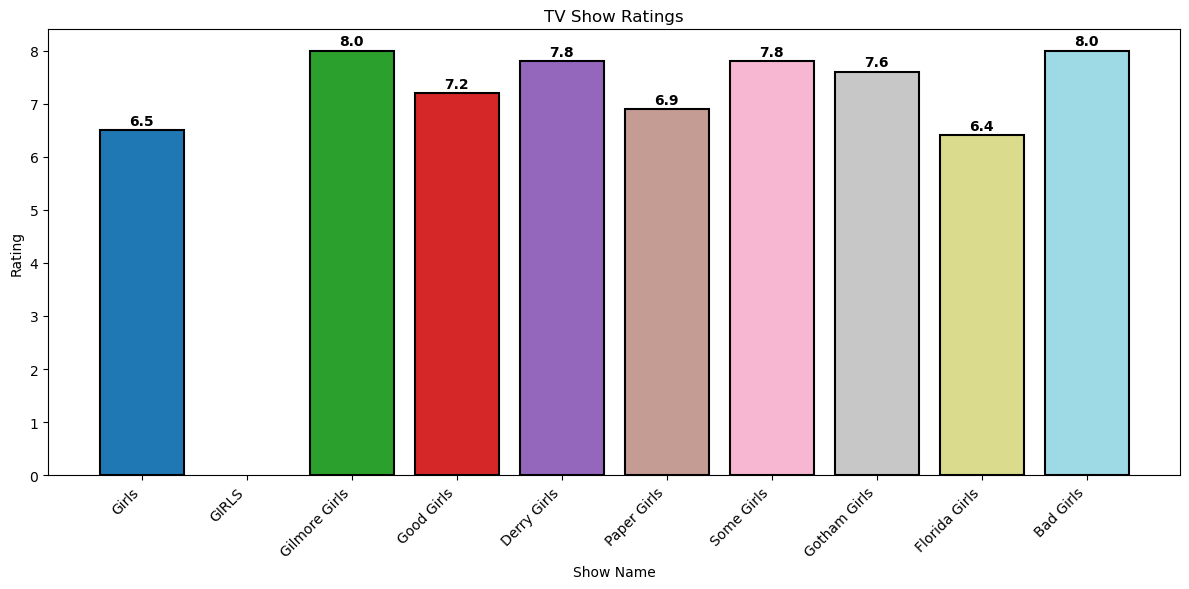

In [35]:
# Chart 1: Ratings Bar Chart
import matplotlib.pyplot as plt
import numpy as np

# Create a distinct color for each bar
colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

plt.figure(figsize=(12,6))

bars = plt.bar(df["name"], df["rating"], color=colors, edgecolor="black", linewidth=1.5)

# Add labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        str(height),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(rotation=45, ha="right")
plt.title("TV Show Ratings")
plt.xlabel("Show Name")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()



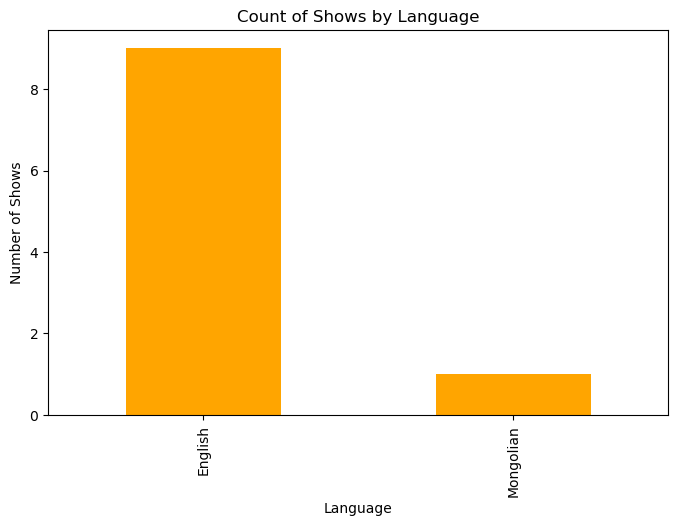

In [32]:
# Count of Shows by Language
lang_counts = df["language"].value_counts()

plt.figure(figsize=(8,5))
lang_counts.plot(kind="bar", color="orange")
plt.title("Count of Shows by Language")
plt.xlabel("Language")
plt.ylabel("Number of Shows")
plt.show()


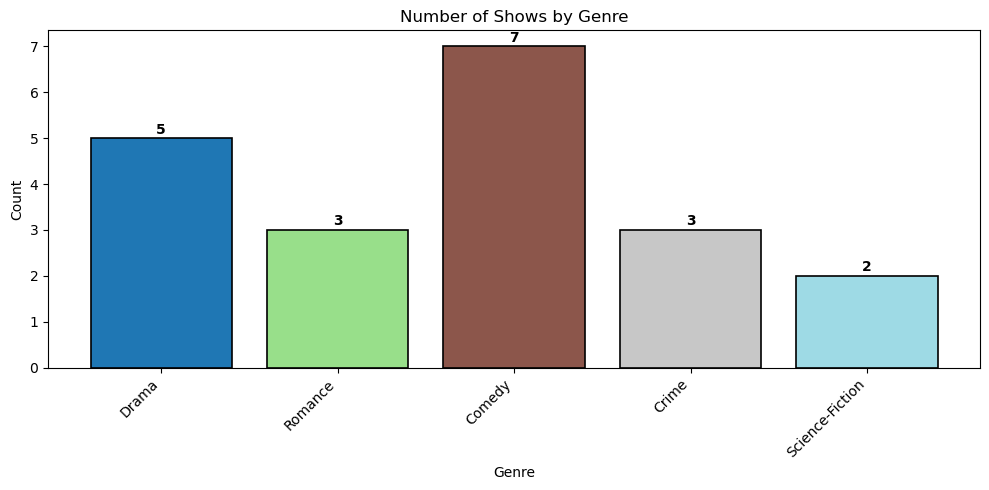

In [47]:
# Number of Shows by Genre
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Build genre list
genre_list = []
for item in data:
    genre_list.extend(item["show"]["genres"])

# Count genres
genre_counts = Counter(genre_list)

# Prepare data
genres = list(genre_counts.keys())
counts = list(genre_counts.values())

# Distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(genres)))

plt.figure(figsize=(10,5))

bars = plt.bar(genres, counts, color=colors, edgecolor="black", linewidth=1.2)

# Add labels on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        str(height),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(rotation=45, ha="right")
plt.title("Number of Shows by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



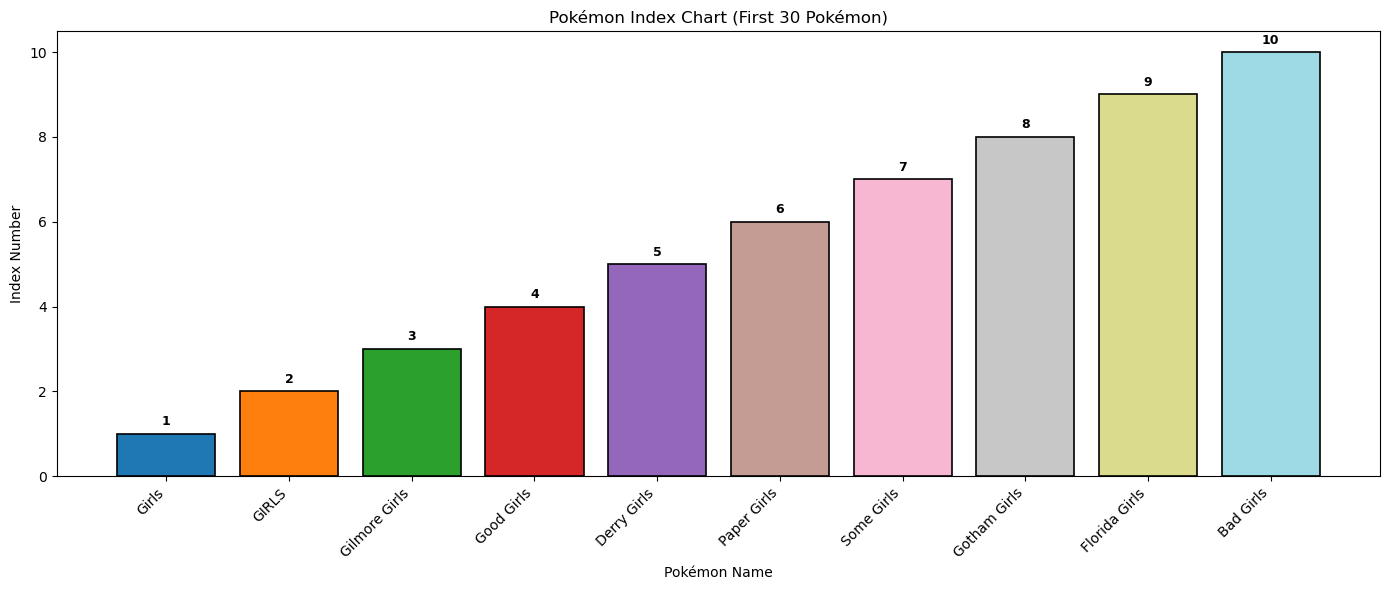

In [37]:
# Distinct Colors + Labels for Each Pokémon Bar
import matplotlib.pyplot as plt
import numpy as np

# Create a numeric index for plotting
df["index"] = range(1, len(df) + 1)

# Generate distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

plt.figure(figsize=(14,6))

bars = plt.bar(df["name"], df["index"], color=colors, edgecolor="black", linewidth=1.2)

# Add labels on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        str(height),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.xticks(rotation=45, ha="right")
plt.title("Pokémon Index Chart (First 30 Pokémon)")
plt.xlabel("Pokémon Name")
plt.ylabel("Index Number")
plt.tight_layout()
plt.show()


In [39]:
# Fetch Full Pokémon Details (Height, Weight, Base Experience, Abilities, Types
import requests
import pandas as pd

# Step 1: Get list of Pokémon (names + URLs)
url = "https://pokeapi.co/api/v2/pokemon?limit=50"
response = requests.get(url)
pokemon_list = response.json()["results"]

# Step 2: Fetch full details for each Pokémon
full_data = []

for p in pokemon_list:
    details = requests.get(p["url"]).json()

    full_data.append({
        "name": details["name"],
        "height": details["height"],
        "weight": details["weight"],
        "base_experience": details["base_experience"],
        "abilities": ", ".join([a["ability"]["name"] for a in details["abilities"]]),
        "types": ", ".join([t["type"]["name"] for t in details["types"]])
    })

# Step 3: Convert to DataFrame
df = pd.DataFrame(full_data)
df


,name,height,weight,base_experience,abilities,types
0,bulbasaur,7,69,64,"overgrow, chlorophyll","grass, poison"
1,ivysaur,10,130,142,"overgrow, chlorophyll","grass, poison"
2,venusaur,20,1000,236,"overgrow, chlorophyll","grass, poison"
3,charmander,6,85,62,"blaze, solar-power",fire
4,charmeleon,11,190,142,"blaze, solar-power",fire
5,charizard,17,905,240,"blaze, solar-power","fire, flying"
6,squirtle,5,90,63,"torrent, rain-dish",water
7,wartortle,10,225,142,"torrent, rain-dish",water
8,blastoise,16,855,239,"torrent, rain-dish",water
9,caterpie,3,29,39,"shield-dust, run-away",bug


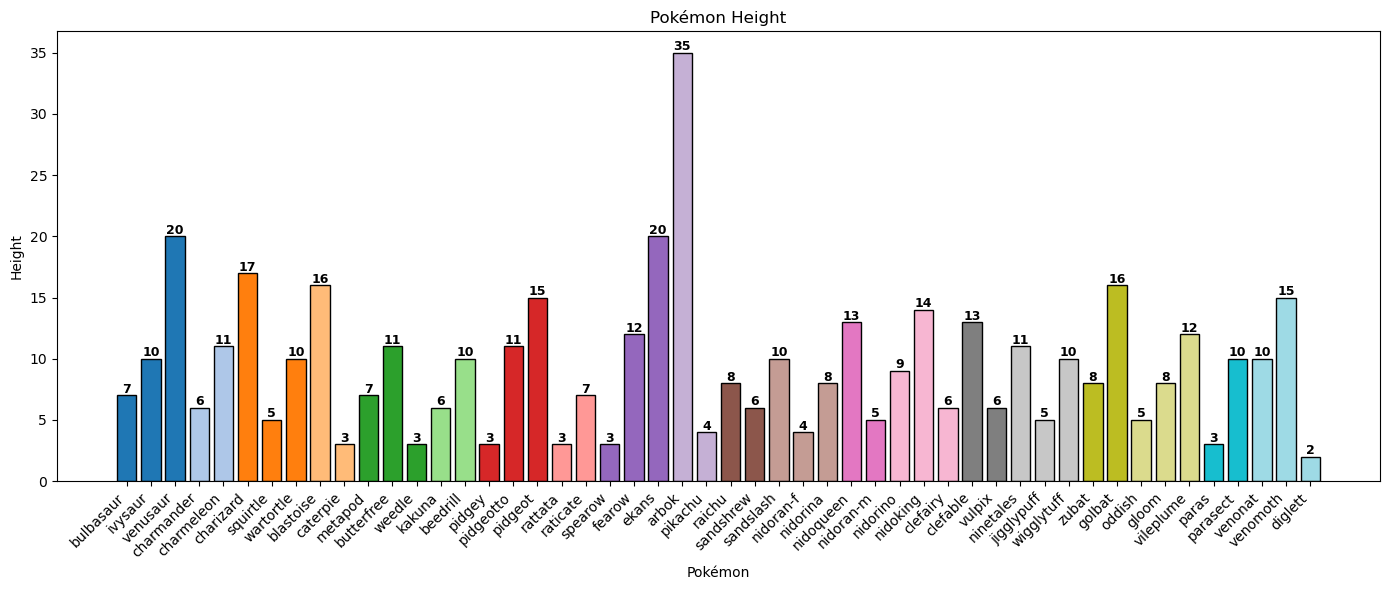

In [40]:
# pokémon Height (Distinct Colors + Labels)
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

colors = plt.cm.tab20(np.linspace(0, 1, len(df)))
bars = plt.bar(df["name"], df["height"], color=colors, edgecolor="black")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(h),
             ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.title("Pokémon Height")
plt.xlabel("Pokémon")
plt.ylabel("Height")
plt.tight_layout()
plt.show()


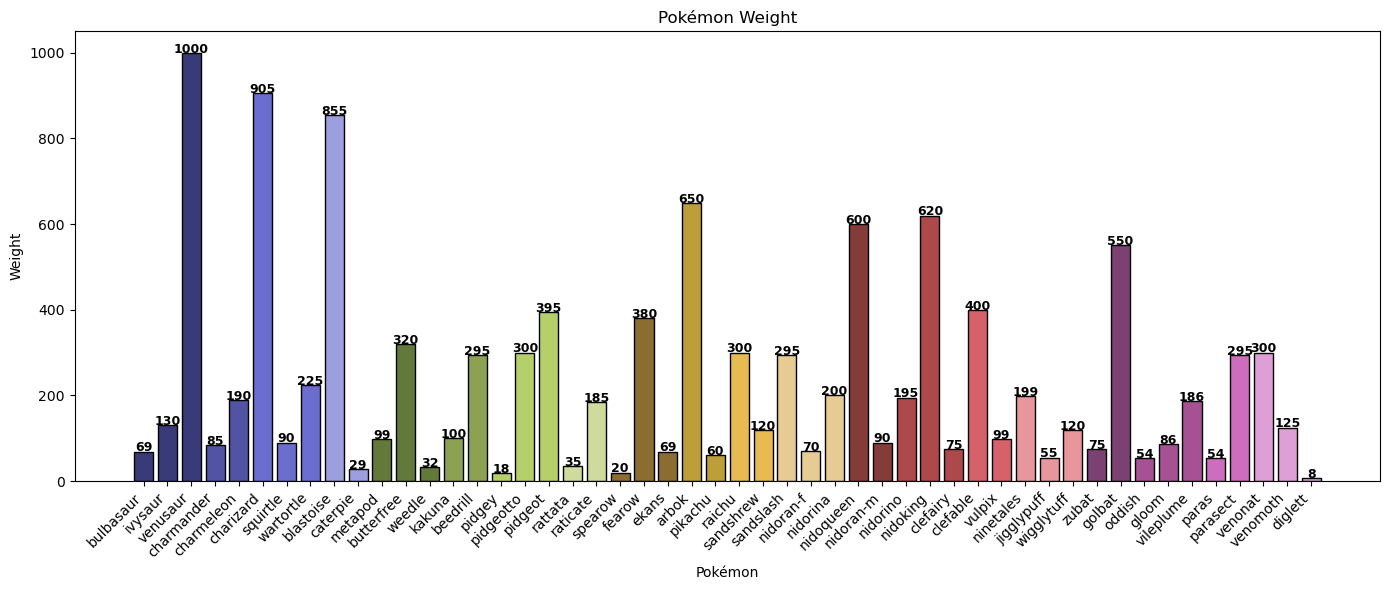

In [41]:
# Pokémon Weight (Distinct Colors + Labels)
plt.figure(figsize=(14,6))

colors = plt.cm.tab20b(np.linspace(0, 1, len(df)))
bars = plt.bar(df["name"], df["weight"], color=colors, edgecolor="black")

for bar in bars:
    w = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, w + 0.2, str(w),
             ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.title("Pokémon Weight")
plt.xlabel("Pokémon")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


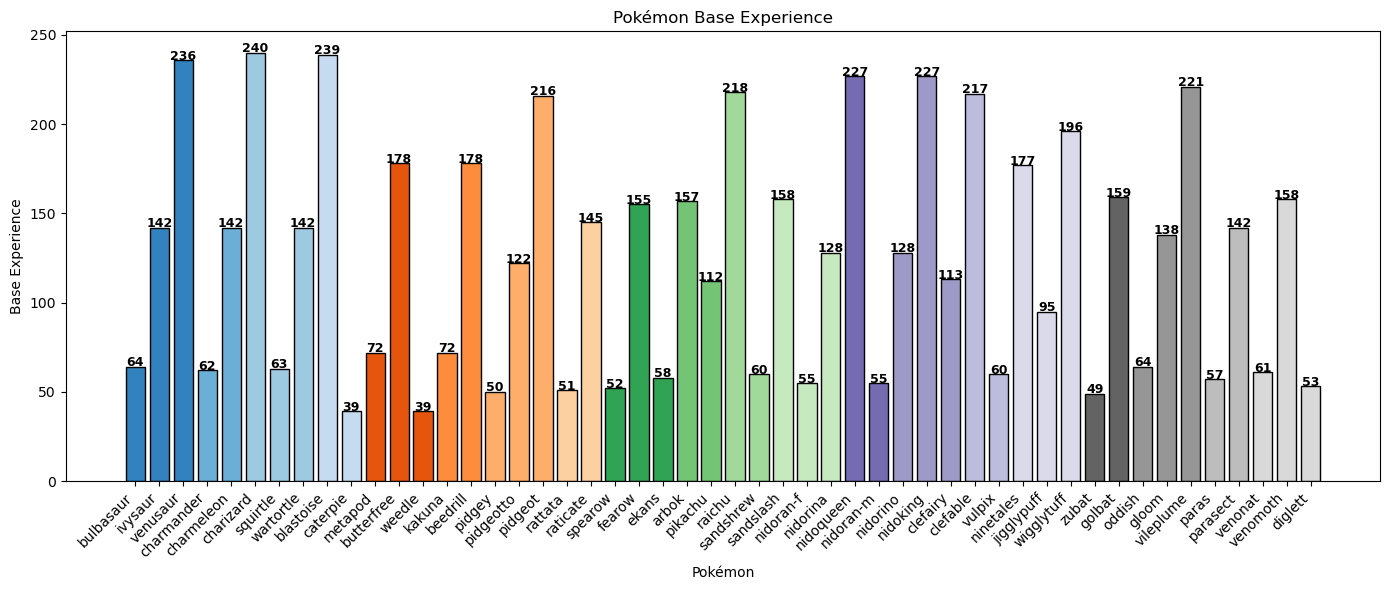

In [42]:
# Base Experience (Distinct Colors + Labels)
plt.figure(figsize=(14,6))

colors = plt.cm.tab20c(np.linspace(0, 1, len(df)))
bars = plt.bar(df["name"], df["base_experience"], color=colors, edgecolor="black")

for bar in bars:
    exp = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, exp + 0.2, str(exp),
             ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.title("Pokémon Base Experience")
plt.xlabel("Pokémon")
plt.ylabel("Base Experience")
plt.tight_layout()
plt.show()


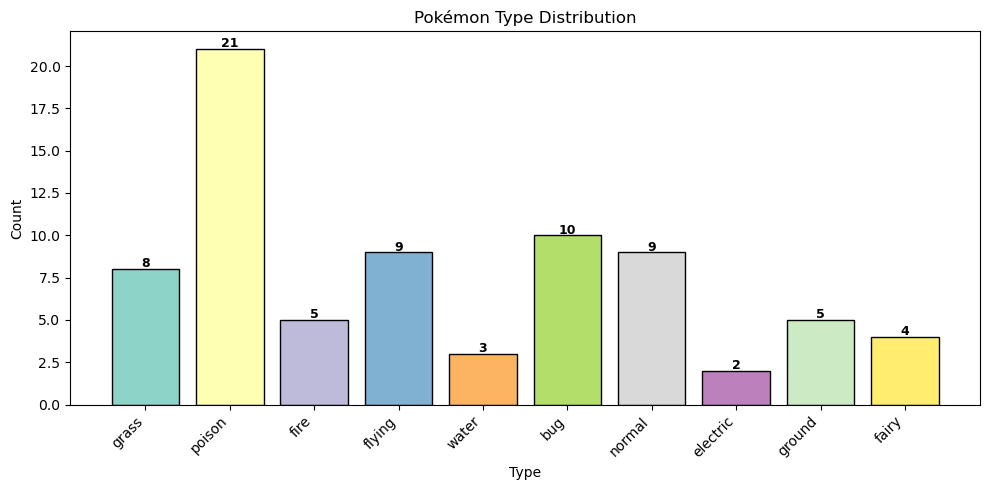

In [43]:
# Abilities & Types (Categorical Charts
from collections import Counter

type_list = []

for t in df["types"]:
    type_list.extend(t.split(", "))

type_counts = Counter(type_list)

plt.figure(figsize=(10,5))
colors = plt.cm.Set3(np.linspace(0, 1, len(type_counts)))

bars = plt.bar(type_counts.keys(), type_counts.values(), color=colors, edgecolor="black")

for bar in bars:
    val = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.1, str(val),
             ha='center', fontsize=9, fontweight='bold')

plt.xticks(rotation=45, ha="right")
plt.title("Pokémon Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython import display

def fetch_crypto():
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        "vs_currency": "usd",
        "per_page": 10,
        "page": 1
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return pd.DataFrame(response.json())
    else:
        print("Error:", response.status_code)
        return None

def live_dashboard():
    while True:
        df = fetch_crypto()
        if df is None:
            time.sleep(5 * 60)
            continue

        names = df["name"]
        prices = df["current_price"]
        change_24h = df["price_change_percentage_24h"]
        market_caps = df["market_cap"]

        colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

        fig = plt.figure(figsize=(18, 10))

        # PRICE
        ax1 = fig.add_subplot(2, 2, 1)
        bars = ax1.bar(names, prices, color=colors, edgecolor="black")
        for bar in bars:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f"{bar.get_height():.2f}", ha="center", fontsize=8)
        ax1.set_title("Crypto Prices (USD)")
        ax1.set_xticklabels(names, rotation=45, ha="right")

        # 24H CHANGE
        ax2 = fig.add_subplot(2, 2, 2)
        bars = ax2.bar(names, change_24h, color=colors, edgecolor="black")
        for bar in bars:
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f"{bar.get_height():.2f}%", ha="center", fontsize=8)
        ax2.set_title("24h Price Change (%)")
        ax2.set_xticklabels(names, rotation=45, ha="right")

        # MARKET CAP
        ax3 = fig.add_subplot(2, 1, 2)
        bars = ax3.bar(names, market_caps, color=colors, edgecolor="black")
        for bar in bars:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f"{bar.get_height()/1e9:.2f}B", ha="center", fontsize=8)
        ax3.set_title("Market Cap (Billions USD)")
        ax3.set_xticklabels(names, rotation=45, ha="right")

        plt.tight_layout()

        # REFRESH DASHBOARD
        display.clear_output(wait=True)
        display.display(fig)

        print("Updated at:", time.ctime())

        time.sleep(5 * 60)  # refresh every 5 minutes

# Run the dashboard
live_dashboard()

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython import display

# Historical storage
price_history = {}
change_history = {}
marketcap_history = {}
timestamps = []

def fetch_crypto():
    url = "https://api.coingecko.com/api/v3/coins/markets"
    params = {
        "vs_currency": "usd",
        "per_page": 10,
        "page": 1
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        return pd.DataFrame(response.json())
    else:
        print("Error:", response.status_code)
        return None

def live_dashboard():
    while True:
        df = fetch_crypto()
        if df is None:
            time.sleep(5 * 60)
            continue

        names = df["name"]
        prices = df["current_price"]
        change_24h = df["price_change_percentage_24h"]
        market_caps = df["market_cap"]

        # Store timestamp
        timestamps.append(time.ctime())

        # Store history for each coin
        for i, name in enumerate(names):
            price_history.setdefault(name, []).append(prices[i])
            change_history.setdefault(name, []).append(change_24h[i])
            marketcap_history.setdefault(name, []).append(market_caps[i])

        fig = plt.figure(figsize=(20, 12))

        # ---------------- PRICE TREND ----------------
        ax1 = fig.add_subplot(3, 1, 1)
        for name in names:
            ax1.plot(price_history[name], marker='o', label=name)
        ax1.set_title("Crypto Price Trend (USD)")
        ax1.set_ylabel("Price")
        ax1.legend(loc="upper left", fontsize=8)

        # ---------------- 24H CHANGE TREND ----------------
        ax2 = fig.add_subplot(3, 1, 2)
        for name in names:
            ax2.plot(change_history[name], marker='o', label=name)
        ax2.set_title("24h Price Change Trend (%)")
        ax2.set_ylabel("% Change")
        ax2.legend(loc="upper left", fontsize=8)

        # ---------------- MARKET CAP TREND ----------------
        ax3 = fig.add_subplot(3, 1, 3)
        for name in names:
            ax3.plot([v/1e9 for v in marketcap_history[name]], marker='o', label=name)
        ax3.set_title("Market Cap Trend (Billions USD)")
        ax3.set_ylabel("Market Cap (Billion USD)")
        ax3.legend(loc="upper left", fontsize=8)

        plt.tight_layout()

        # REFRESH DASHBOARD
        display.clear_output(wait=True)
        display.display(fig)

        print("Updated at:", time.ctime())

        time.sleep(5 * 60)  # refresh every 5 minutes

# Run the dashboard
live_dashboard()